In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from tabulate import tabulate
%matplotlib inline

import seaborn as sns
sns.set(style='whitegrid', palette='muted', color_codes=True)

# For predictive modeling
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.inspection import permutation_importance

# Set random seed for reproducibility
np.random.seed(42)
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load the datasets
train = pd.read_csv('/content/train.csv', encoding='UTF-8-SIG')
test = pd.read_csv('/content/train.csv', encoding='UTF-8-SIG')

print('Train and test data loaded.')

# Display first few rows (this will be generated upon execution)
train.head()

Train and test data loaded.


,Date,Region,Brand,Model,Vehicle_Type,Battery_Capacity_kWh,Discount_Percentage,Customer_Segment,Fast_Charging_Option,Units_Sold,Revenue
0,2023-07,Oceania,Toyota,i4,Crossover,62,6,High Income,No,260,3699780
1,2023-03,Oceania,Toyota,Leaf,Truck,70,19,High Income,Yes,347,7801424
2,2023-05,North America,Toyota,ID.5,Crossover,81,13,Middle Income,No,294,4813013
3,2023-02,Oceania,Tesla,Corolla EV,Truck,73,4,High Income,Yes,281,7484912
4,2023-10,North America,BYD,Leaf,Coupe,52,4,High Income,No,166,4025360


In [7]:
# Convert Date column to datetime for both datasets
for df in [train, test]:
    # Try converting Date column. If there is an error, it might be a format issue that others could also face.
    try:
        df['Date'] = pd.to_datetime(df['Date'])
    except Exception as e:
        print(f"Error converting Date: {e}")
        # Handling may include specifying a format if known or errors='coerce'
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [8]:
# Extract additional date-based features (year and month) as they might be useful for analysis and prediction
for df in [train, test]:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month

print('Date column converted and new date features extracted.')

Date column converted and new date features extracted.


In [5]:
# Check for missing values
print(train.isnull().sum())

Date                    0
Region                  0
Brand                   0
Model                   0
Vehicle_Type            0
Battery_Capacity_kWh    0
Discount_Percentage     0
Customer_Segment        0
Fast_Charging_Option    0
Units_Sold              0
Revenue                 0
dtype: int64


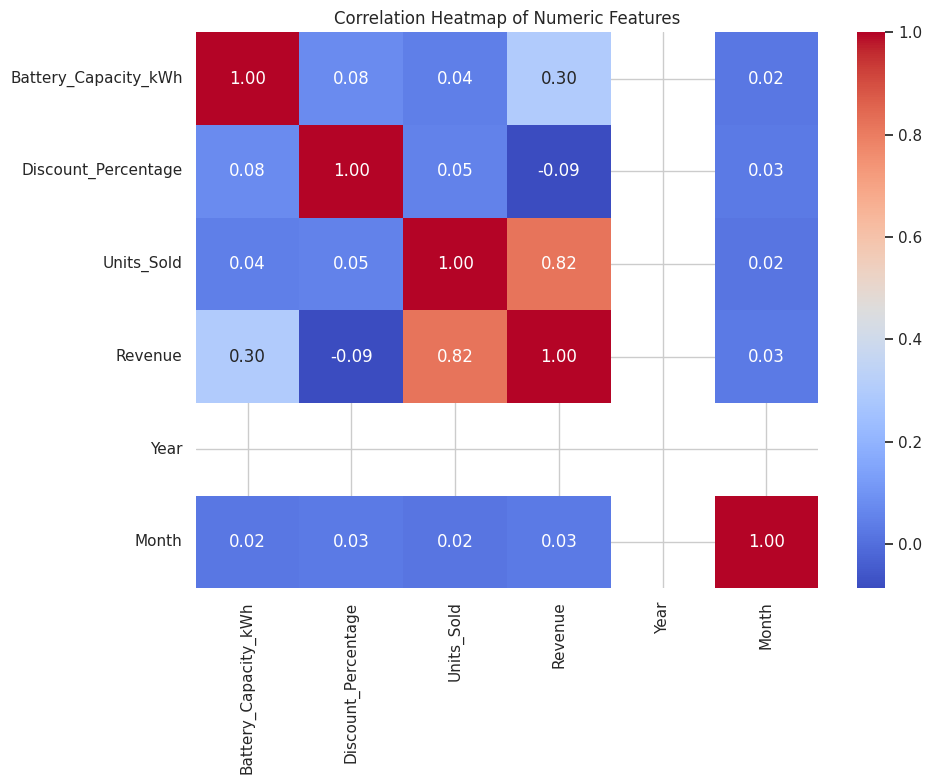

In [9]:
# Select numeric columns from the training data for correlation analysis
numeric_df = train.select_dtypes(include=[np.number])

if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap.')

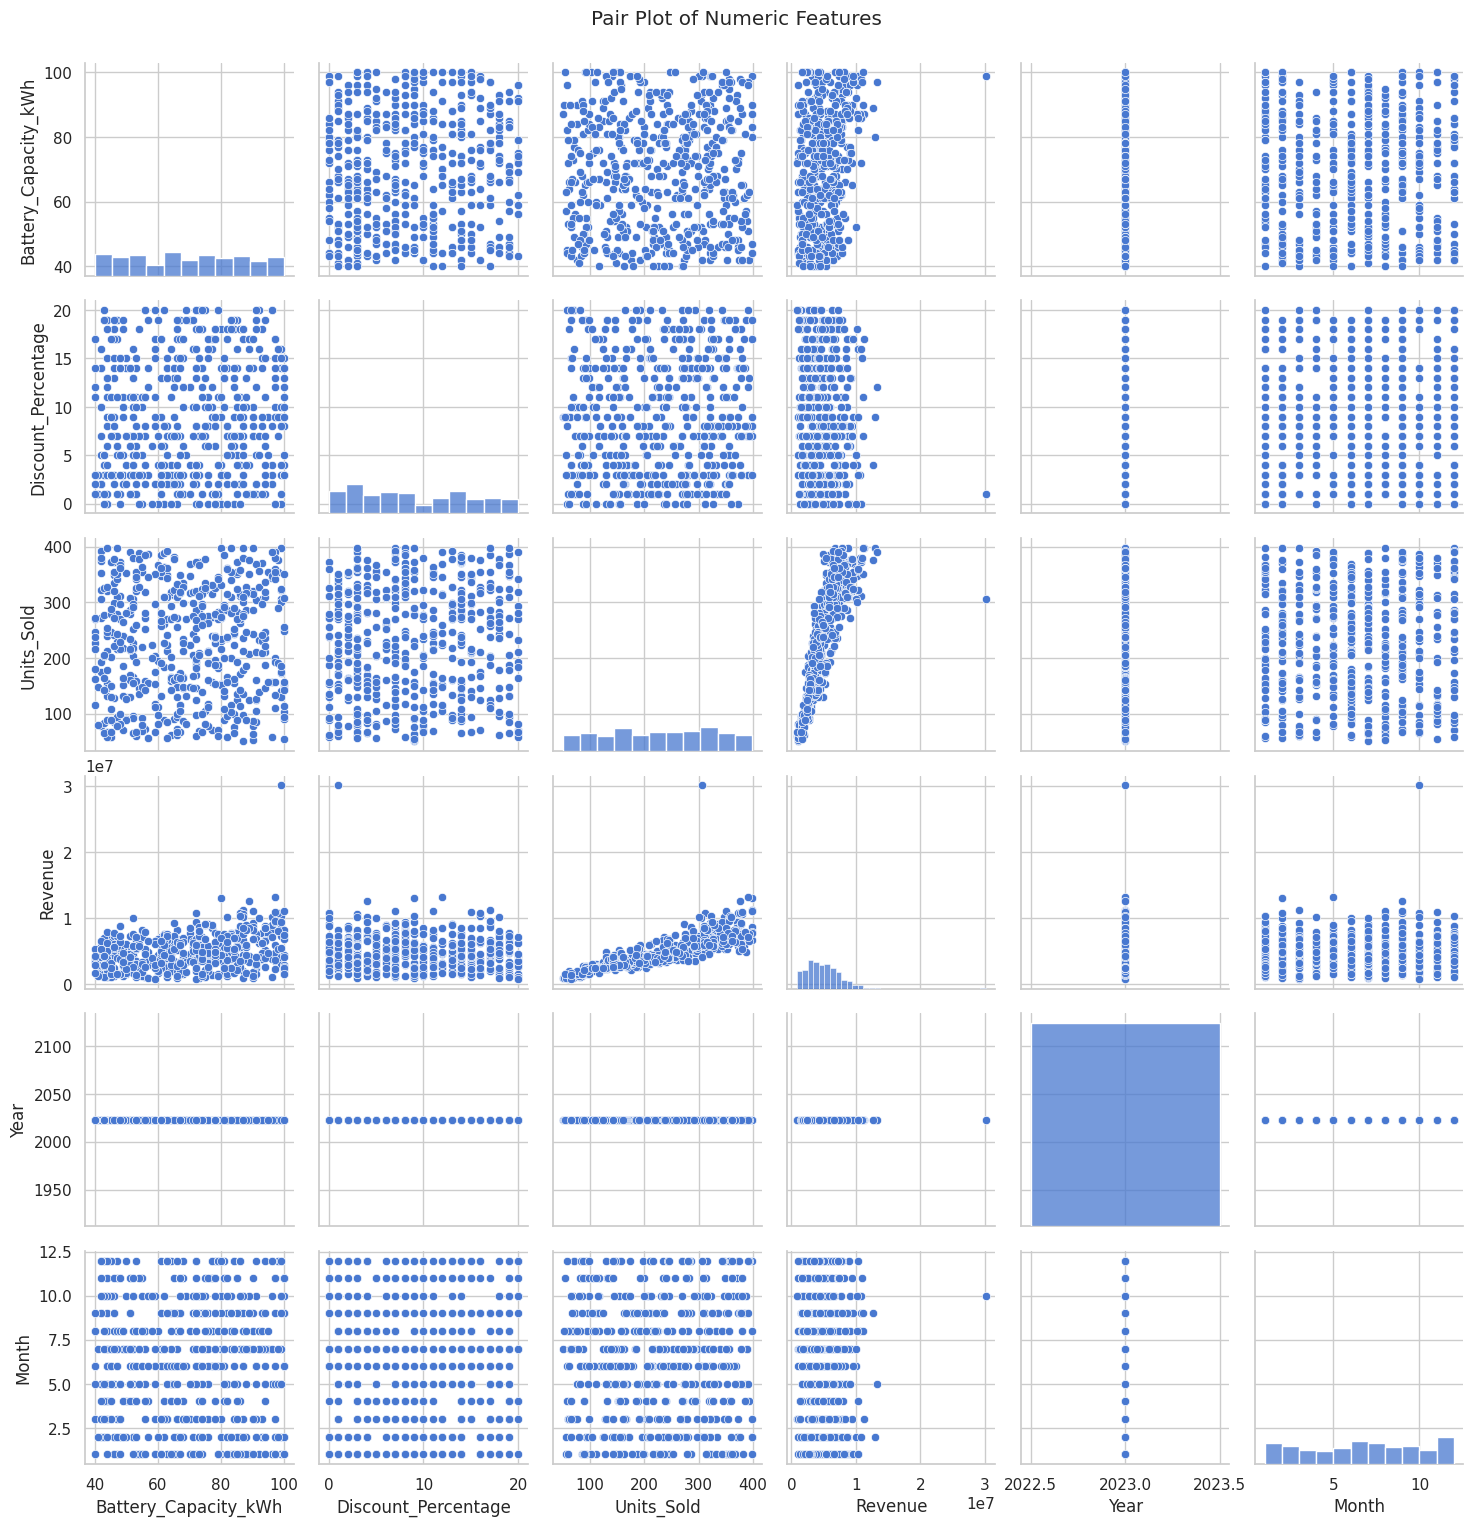

In [10]:
# Pair Plot for numeric features
sns.pairplot(numeric_df.dropna())
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

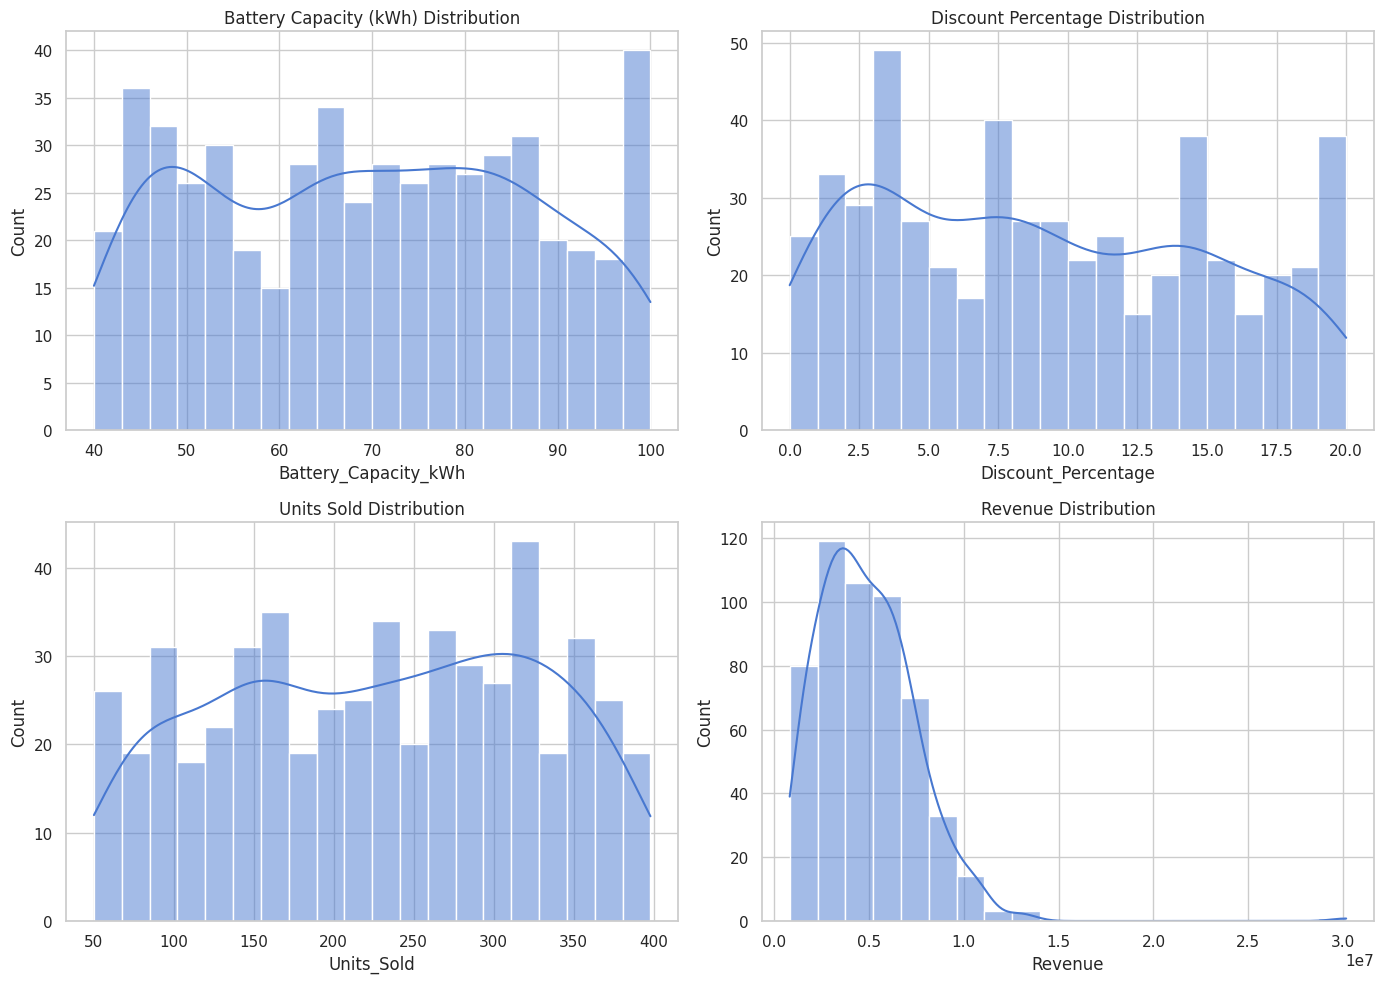

In [11]:
# Histograms for key numeric attributes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(train['Battery_Capacity_kWh'], bins=20, ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Battery Capacity (kWh) Distribution')

sns.histplot(train['Discount_Percentage'], bins=20, ax=axes[0, 1], kde=True)
axes[0, 1].set_title('Discount Percentage Distribution')

sns.histplot(train['Units_Sold'], bins=20, ax=axes[1, 0], kde=True)
axes[1, 0].set_title('Units Sold Distribution')

sns.histplot(train['Revenue'], bins=20, ax=axes[1, 1], kde=True)
axes[1, 1].set_title('Revenue Distribution')

plt.tight_layout()
plt.show()


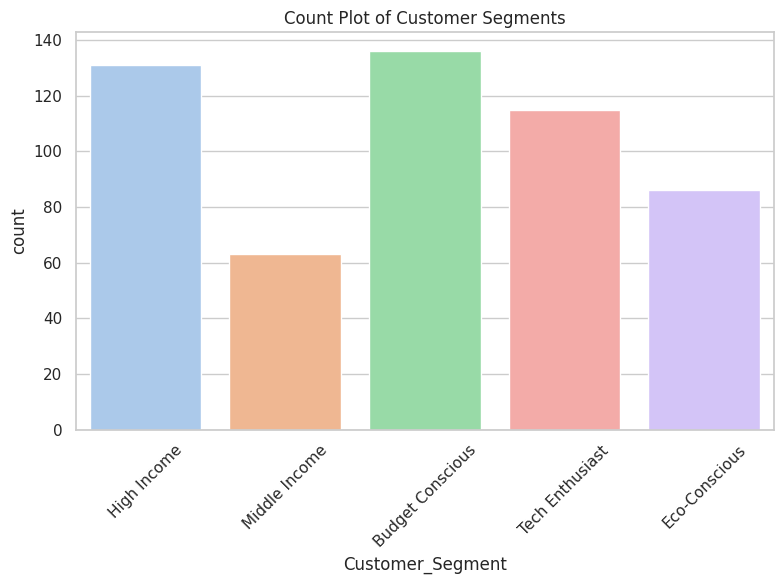

In [12]:
# Countplot for categorical: Customer_Segment
plt.figure(figsize=(8, 6))
sns.countplot(data=train, x='Customer_Segment', palette='pastel')
plt.title('Count Plot of Customer Segments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

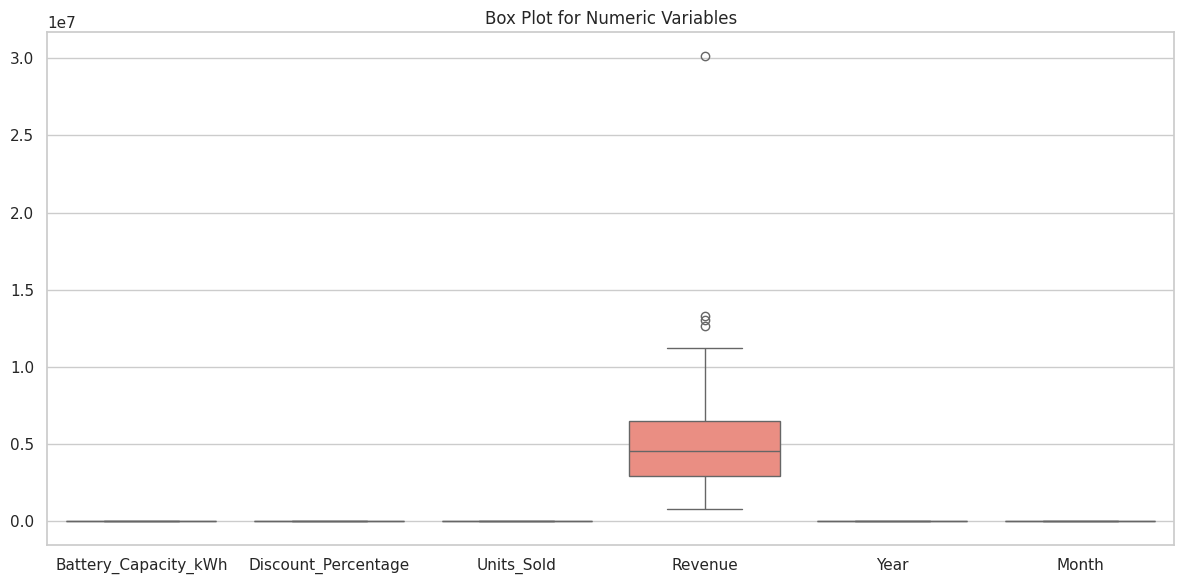

In [13]:
# Box plots for numeric features
plt.figure(figsize=(12,6))
sns.boxplot(data=numeric_df, palette='Set3')
plt.title('Box Plot for Numeric Variables')
plt.tight_layout()
plt.show()